Mounted at /content/drive
Dataset folder found: /content/drive/MyDrive/Instacart

Files inside dataset folder:
- aisles.csv
- departments.csv
- order_products__prior.csv
- order_products__train.csv
- orders.csv
- phase1_outputs
- phase2_outputs
- phase3_outputs
- phase3_outputs_final
- phase4_lstm_relu_batch
- phase4_outputs
- phase4_outputs_final
- phase4_outputs_gru_relu_5epochs
- phase4_outputs_gru_relu_stable
- phase4_outputs_gru_relu_swilu_stable
- phase4_outputs_light_singlecell
- phase4_outputs_lstm_relu_gelu_stable
- phase4_outputs_transformer_encoder_gelu_nan_safe
- phase4_outputs_transformer_encoder_gelu_nan_safe_v2
- phase4_outputs_transformer_encoder_gelu_stable
- phase4_topk_extra_model_outputs
- products.csv

All required Instacart files are available.

All files loaded successfully from Google Drive.

DATASET: Aisles
Shape: (134, 2)


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation



Data types:
aisle_id     int64
aisle       object
dtype: object

Missing values:
aisle_id    0
aisle       0
dtype: int64

DATASET: Departments
Shape: (21, 2)


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol



Data types:
department_id     int64
department       object
dtype: object

Missing values:
department_id    0
department       0
dtype: int64

DATASET: Products
Shape: (49688, 4)


...


Data types:
order_id                    int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object

Missing values:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

DATASET: Order Products Prior
Shape: (32434489, 4)


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0



Data types:
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object

Missing values:
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

DATASET: Order Products Train
Shape: (1384617, 4)


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1



Data types:
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object

Missing values:
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

User order summary statistics:
count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: order_number, dtype: float64


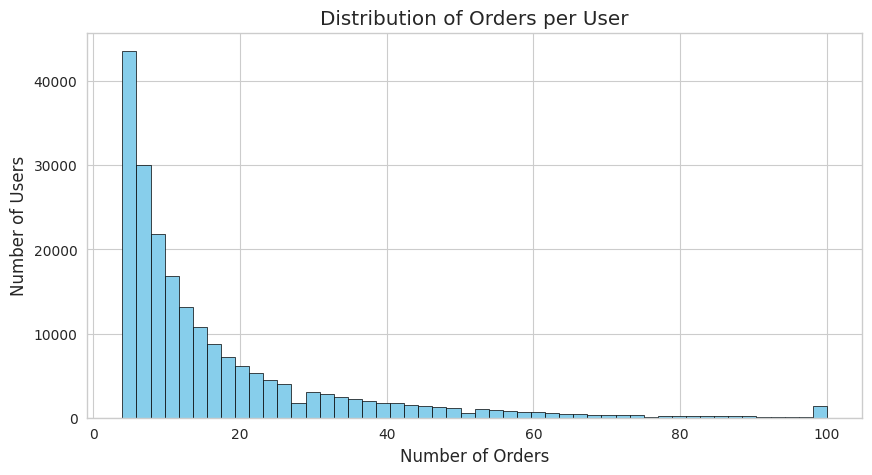

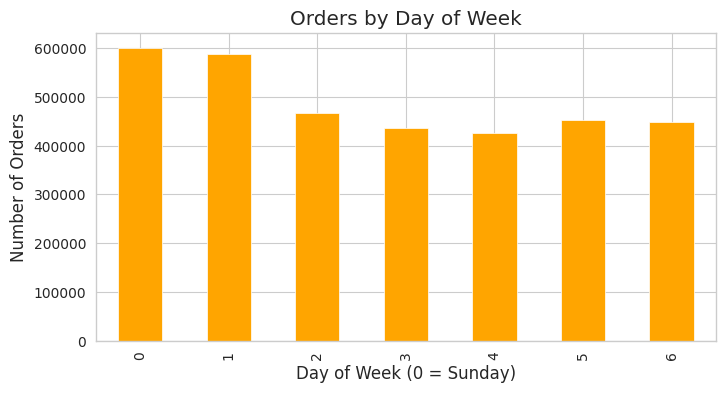

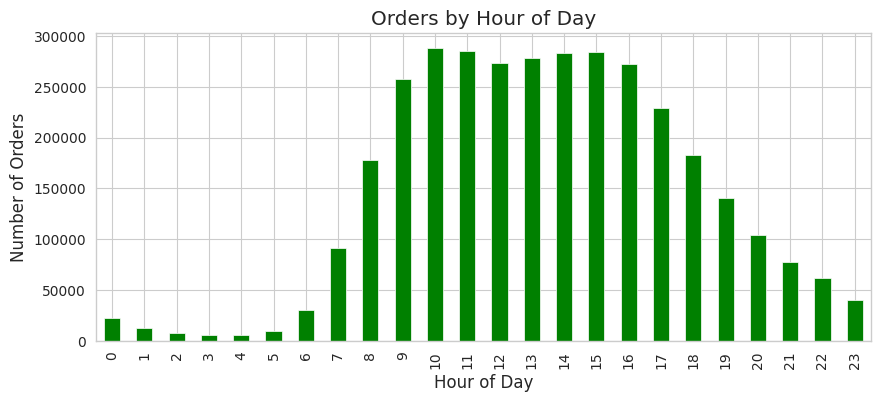


Overall Reorder Rate: 0.5897


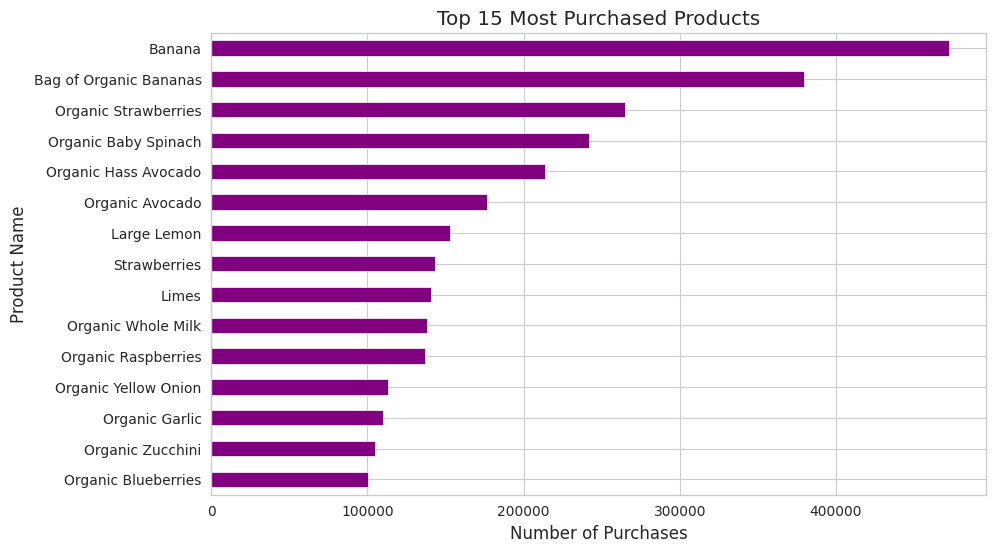

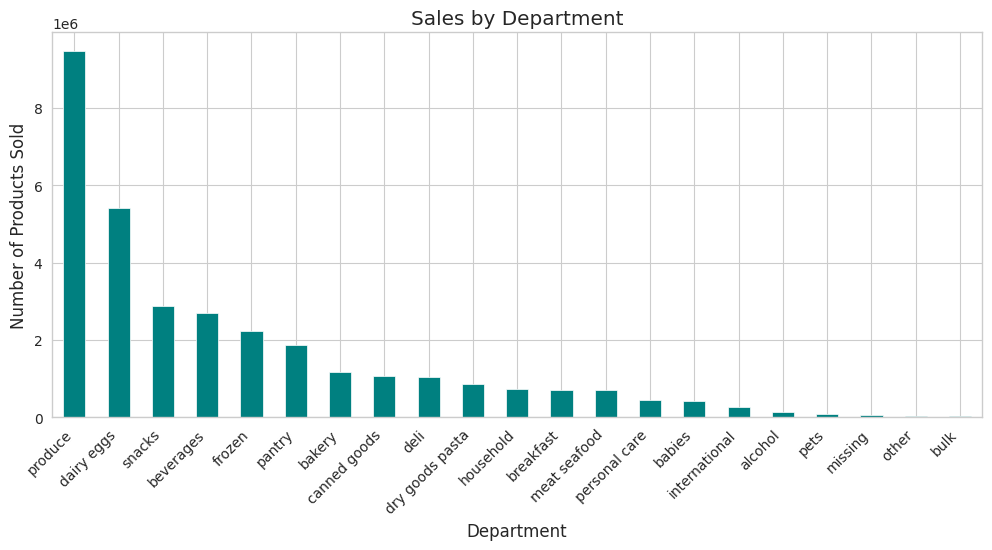

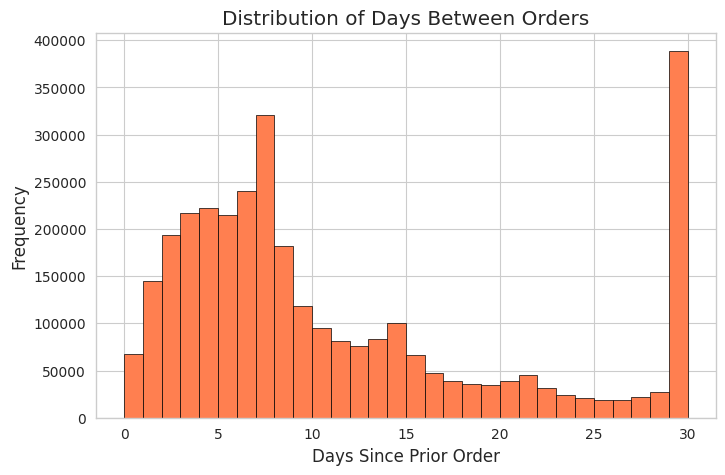

Missing values after fix:
0

First-order flag distribution:
is_first_order
0    3214874
1     206209
Name: count, dtype: int64

EDA outputs saved to: /content/drive/MyDrive/Instacart/phase1_outputs


In [ ]:
# =========================================
# PHASE 1: DATA UNDERSTANDING + EDA
# INSTACART MARKET BASKET ANALYSIS
# GOOGLE COLAB - READ DIRECTLY FROM DRIVE
# =========================================

# ================================
# STEP 1: MOUNT GOOGLE DRIVE
# ================================
from google.colab import drive
drive.mount('/content/drive')

# ================================
# STEP 2: IMPORT LIBRARIES
# ================================
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use("ggplot")
sns.set_style("whitegrid")

# ================================
# STEP 3: SET DATA FOLDER IN DRIVE
# ================================
# Change this only once based on your Drive folder
DATA_PATH = Path("/content/drive/MyDrive/Instacart")

# Check whether folder exists
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATA_PATH}")

print("Dataset folder found:", DATA_PATH)
print("\nFiles inside dataset folder:")
for f in sorted(DATA_PATH.iterdir()):
    print("-", f.name)

# ================================
# STEP 4: DEFINE FILE PATHS
# ================================
AISLES_FILE = DATA_PATH / "aisles.csv"
DEPARTMENTS_FILE = DATA_PATH / "departments.csv"
PRODUCTS_FILE = DATA_PATH / "products.csv"
ORDERS_FILE = DATA_PATH / "orders.csv"
PRIOR_FILE = DATA_PATH / "order_products__prior.csv"
TRAIN_FILE = DATA_PATH / "order_products__train.csv"

required_files = [
    AISLES_FILE,
    DEPARTMENTS_FILE,
    PRODUCTS_FILE,
    ORDERS_FILE,
    PRIOR_FILE,
    TRAIN_FILE
]

missing_files = [str(f) for f in required_files if not f.exists()]
if missing_files:
    raise FileNotFoundError("Missing files:\n" + "\n".join(missing_files))

print("\nAll required Instacart files are available.")

# ================================
# STEP 5: LOAD ALL CSV FILES FROM DRIVE
# ================================
aisles = pd.read_csv(AISLES_FILE)
departments = pd.read_csv(DEPARTMENTS_FILE)
products = pd.read_csv(PRODUCTS_FILE)
orders = pd.read_csv(ORDERS_FILE)
order_products_prior = pd.read_csv(PRIOR_FILE)
order_products_train = pd.read_csv(TRAIN_FILE)

print("\nAll files loaded successfully from Google Drive.")

# ================================
# STEP 6: QUICK OVERVIEW FUNCTION
# ================================
def explore_dataset(df, name):
    print("\n" + "="*70)
    print(f"DATASET: {name}")
    print("="*70)
    print("Shape:", df.shape)
    display(df.head())
    print("\nData types:")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isnull().sum())

# ================================
# STEP 7: EXPLORE ALL TABLES
# ================================
explore_dataset(aisles, "Aisles")
explore_dataset(departments, "Departments")
explore_dataset(products, "Products")
explore_dataset(orders, "Orders")
explore_dataset(order_products_prior, "Order Products Prior")
explore_dataset(order_products_train, "Order Products Train")

# ================================
# STEP 8: USER ORDER ANALYSIS
# ================================
user_order_counts = orders.groupby("user_id")["order_number"].max()

print("\nUser order summary statistics:")
print(user_order_counts.describe())

plt.figure(figsize=(10, 5))
plt.hist(user_order_counts, bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of Orders per User")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Users")
plt.show()

# ================================
# STEP 9: TIME-BASED ANALYSIS
# ================================
plt.figure(figsize=(8, 4))
orders["order_dow"].value_counts().sort_index().plot(kind="bar", color="orange")
plt.title("Orders by Day of Week")
plt.xlabel("Day of Week (0 = Sunday)")
plt.ylabel("Number of Orders")
plt.show()

plt.figure(figsize=(10, 4))
orders["order_hour_of_day"].value_counts().sort_index().plot(kind="bar", color="green")
plt.title("Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.show()

# ================================
# STEP 10: REORDER ANALYSIS
# ================================
reorder_rate = order_products_prior["reordered"].mean()
print("\nOverall Reorder Rate:", round(reorder_rate, 4))

# ================================
# STEP 11: TOP PRODUCTS
# ================================
top_products = (
    order_products_prior
    .merge(products, on="product_id", how="left")
    .groupby("product_name")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind="barh", color="purple")
plt.title("Top 15 Most Purchased Products")
plt.xlabel("Number of Purchases")
plt.ylabel("Product Name")
plt.show()

# ================================
# STEP 12: DEPARTMENT ANALYSIS
# ================================
dept_sales = (
    order_products_prior
    .merge(products, on="product_id", how="left")
    .merge(departments, on="department_id", how="left")
    .groupby("department")["product_id"]
    .count()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
dept_sales.plot(kind="bar", color="teal")
plt.title("Sales by Department")
plt.xlabel("Department")
plt.ylabel("Number of Products Sold")
plt.xticks(rotation=45, ha="right")
plt.show()

# ================================
# STEP 13: DAYS SINCE PRIOR ORDER
# ================================
plt.figure(figsize=(8, 5))
orders["days_since_prior_order"].dropna().hist(
    bins=30, color="coral", edgecolor="black"
)
plt.title("Distribution of Days Between Orders")
plt.xlabel("Days Since Prior Order")
plt.ylabel("Frequency")
plt.show()

# ================================
# STEP 14: SAVE OUTPUTS BACK TO DRIVE
# ================================
OUTPUT_PATH = DATA_PATH / "phase1_outputs"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

user_order_counts.to_csv(OUTPUT_PATH / "user_order_counts.csv")
top_products.to_csv(OUTPUT_PATH / "top_products.csv")
dept_sales.to_csv(OUTPUT_PATH / "department_sales.csv")
# ================================
# STEP: HANDLE MISSING VALUES IN days_since_prior_order
# ================================

# 1. Create a flag to identify first order of each user
# NaN means "no previous order exists"
orders["is_first_order"] = orders["days_since_prior_order"].isna().astype(int)

# 2. Fill missing values with 0 (safe placeholder)
# We already captured meaning using is_first_order
orders["days_since_prior_order"] = orders["days_since_prior_order"].fillna(0)

# ================================
# VERIFICATION
# ================================

print("Missing values after fix:")
print(orders["days_since_prior_order"].isnull().sum())

print("\nFirst-order flag distribution:")
print(orders["is_first_order"].value_counts())

# Preview updated dataset
orders.head()

print(f"\nEDA outputs saved to: {OUTPUT_PATH}")

In [ ]:
# ================================
# STEP: HANDLE MISSING VALUES IN days_since_prior_order
# ================================

# 1. Create a flag to identify first order of each user
# NaN means "no previous order exists"
orders["is_first_order"] = orders["days_since_prior_order"].isna().astype(int)

# 2. Fill missing values with 0 (safe placeholder)
# We already captured meaning using is_first_order
orders["days_since_prior_order"] = orders["days_since_prior_order"].fillna(0)

# ================================
# VERIFICATION
# ================================

print("Missing values after fix:")
print(orders["days_since_prior_order"].isnull().sum())

print("\nFirst-order flag distribution:")
print(orders["is_first_order"].value_counts())

# Preview updated dataset
orders.head()

Missing values after fix:
0

First-order flag distribution:
is_first_order
0    3421083
Name: count, dtype: int64


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,is_first_order
0,2539329,1,prior,1,2,8,0.0,0
1,2398795,1,prior,2,3,7,15.0,0
2,473747,1,prior,3,3,12,21.0,0
3,2254736,1,prior,4,4,7,29.0,0
4,431534,1,prior,5,4,15,28.0,0


In [ ]:
# Check if order_number == 1 exists at all
orders["order_number"].value_counts().head(10)

,count
order_number,
1,206209
2,206209
3,206209
4,206209
5,182223
6,162633
7,146468
8,132618
9,120918


In [ ]:
# ================================
# SAFE REBUILD OF FIRST ORDER FLAG
# ================================

# Ensure correct dataset (no filtering issues)
orders = orders.copy()

# First order definition is strictly order_number == 1
orders["is_first_order"] = (orders["order_number"] == 1).astype(int)

# Fill missing time gaps
orders["days_since_prior_order"] = orders["days_since_prior_order"].fillna(0)

# ================================
# VERIFY CORRECTNESS
# ================================

print("First-order distribution:")
print(orders["is_first_order"].value_counts())

print("\nSanity check (should show order_number=1 exists):")
print(orders["order_number"].value_counts().head())

First-order distribution:
is_first_order
0    3214874
1     206209
Name: count, dtype: int64

Sanity check (should show order_number=1 exists):
order_number
1    206209
2    206209
3    206209
4    206209
5    182223
Name: count, dtype: int64


In [ ]:
# Merge prior orders with product names
order_products = order_products_prior.merge(
    products[["product_id", "product_name"]],
    on="product_id",
    how="left"
)

order_products = order_products.merge(
    orders[["order_id", "user_id", "order_number"]],
    on="order_id",
    how="left"
)

In [ ]:
# Create product sequences per user per order
user_sequences = (
    order_products
    .sort_values(["user_id", "order_number"])
    .groupby(["user_id", "order_number"])["product_id"]
    .apply(list)
    .reset_index()
)

user_sequences.head()

,user_id,order_number,product_id
0,1,1,"[196, 14084, 12427, 26088, 26405]"
1,1,2,"[196, 10258, 12427, 13176, 26088, 13032]"
2,1,3,"[196, 12427, 10258, 25133, 30450]"
3,1,4,"[196, 12427, 10258, 25133, 26405]"
4,1,5,"[196, 12427, 10258, 25133, 10326, 17122, 41787..."


In [ ]:
# Convert into full user-level sequences
user_full_sequences = (
    user_sequences
    .groupby("user_id")["product_id"]
    .apply(list)
)

In [ ]:
print("Number of users:", len(user_full_sequences))
print("\nSample user:")
print(user_full_sequences.head())

Number of users: 206209

Sample user:
user_id
1    [[196, 14084, 12427, 26088, 26405], [196, 1025...
2    [[32792, 47766, 20574, 12000, 48110, 22474, 16...
3    [[9387, 17668, 15143, 16797, 39190, 47766, 219...
4    [[36606, 7350, 35469, 2707], [42329, 7160], [1...
5    [[15349, 21413, 48775, 28289, 8518, 11777, 317...
Name: product_id, dtype: object


In [ ]:
# check one user structure
sample_user = user_full_sequences.index[0]

print("User ID:", sample_user)
print("Type:", type(user_full_sequences[sample_user]))
print("First few orders:", user_full_sequences[sample_user][:3])

User ID: 1
Type: <class 'list'>
First few orders: [[196, 14084, 12427, 26088, 26405], [196, 10258, 12427, 13176, 26088, 13032], [196, 12427, 10258, 25133, 30450]]


In [ ]:

def check_order_consistency(user_id):
    orders = user_sequences[user_sequences["user_id"] == user_id]
    return orders["order_number"].is_monotonic_increasing

sample_users = user_sequences["user_id"].unique()[:5]

for u in sample_users:
    print(u, check_order_consistency(u))


1 True
2 True
3 True
4 True
5 True


In [ ]:
import numpy as np

lengths = user_full_sequences.apply(len)

print("Stats of user sequence length:")
print(lengths.describe())

Stats of user sequence length:
count    206209.000000
mean         15.590367
std          16.654774
min           3.000000
25%           5.000000
50%           9.000000
75%          19.000000
max          99.000000
Name: product_id, dtype: float64


In [ ]:
all_products = set()

for seq in user_full_sequences[:1000]:
    for order in seq:
        all_products.update(order)

print("Unique products in sample:", len(all_products))

Unique products in sample: 15214


# Phase 2


In [ ]:
# =========================================
# PHASE 2 CONFIGURATION
# =========================================

from pathlib import Path
import os
import pickle
import numpy as np
import pandas as pd

# ================================
# HYPERPARAMETERS (YOUR SETTINGS)
# ================================
MAX_LEN = 50
MIN_USER_SEQ = 5
VOCAB_SIZE = 25000
TRAIN_SPLIT = 0.8

# ================================
# SAVE PATH (GOOGLE DRIVE)
# ================================
BASE_PATH = Path("/content/drive/MyDrive/Instacart/phase2_outputs")
BASE_PATH.mkdir(parents=True, exist_ok=True)

print("Phase 2 outputs will be saved in:", BASE_PATH)

Phase 2 outputs will be saved in: /content/drive/MyDrive/Instacart/phase2_outputs


In [ ]:
# =========================================
# CHECKPOINT UTILITIES
# =========================================

def save_pickle(obj, name):
    path = BASE_PATH / name
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"Saved → {name}")

def load_pickle(name):
    path = BASE_PATH / name
    if path.exists():
        with open(path, "rb") as f:
            print(f"Loaded → {name}")
            return pickle.load(f)
    return None

In [ ]:
# =========================================
# STEP 1: USER SEQUENCES
# =========================================

user_sequences = load_pickle("user_sequences.pkl")

if user_sequences is None:
    print("Creating user sequences...")

    # expects you already have order_products merged in Phase 1
    user_sequences = (
        order_products
        .sort_values(["user_id", "order_number"])
        .groupby("user_id")["product_id"]
        .apply(list)
    )

    save_pickle(user_sequences, "user_sequences.pkl")

print("Total users:", len(user_sequences))

Loaded → user_sequences.pkl
Total users: 206209


In [ ]:
# =========================================
# STEP 2: FILTER SHORT SEQUENCES
# =========================================

filtered_users = user_sequences[user_sequences.apply(len) >= MIN_USER_SEQ]

print("Users after filtering:", len(filtered_users))

Users after filtering: 205414


In [ ]:
print(MIN_USER_SEQ, "is the minimum sequence length.")


5 is the minimum sequence length.


In [ ]:
sample_user = filtered_users.iloc[0]
print(sample_user)
print(type(sample_user))
print("First element:", sample_user[0])
print("Type of first element:", type(sample_user[0]))

[196, 14084, 12427, 26088, 26405, 196, 10258, 12427, 13176, 26088, 13032, 196, 12427, 10258, 25133, 30450, 196, 12427, 10258, 25133, 26405, 196, 12427, 10258, 25133, 10326, 17122, 41787, 13176, 196, 12427, 10258, 25133, 196, 10258, 12427, 25133, 13032, 12427, 196, 10258, 25133, 46149, 49235, 49235, 46149, 25133, 196, 10258, 12427, 196, 46149, 39657, 38928, 25133, 10258, 35951, 13032, 12427]
<class 'list'>
First element: 196
Type of first element: <class 'int'>


In [ ]:
# =========================================
# STEP 3: VOCAB BUILD (ROBUST + SUBMISSION READY)
# =========================================

from collections import Counter
import numpy as np

product_freq = Counter()

# -------------------------
# SAFE ITERATION
# -------------------------
for seq in filtered_users:

    # FIX: ensure seq is iterable list
    if isinstance(seq, (list, np.ndarray)):
        for p in seq:
            product_freq[p] += 1


# -------------------------
# SORT + LIMIT VOCAB
# -------------------------
sorted_products = product_freq.most_common(VOCAB_SIZE)

top_products = [p[0] for p in sorted_products]


# -------------------------
# CREATE MAPPINGS
# -------------------------
product2id = {p: i + 1 for i, p in enumerate(top_products)}

# Add UNK token (VERY IMPORTANT)
product2id["<UNK>"] = 0


# -------------------------
# SAVE FUNCTION (ensure consistent reuse)
# -------------------------
def save_pickle(obj, name):
    import pickle
    with open(name, "wb") as f:
        pickle.dump(obj, f)


save_pickle(product2id, "product2id.pkl")


# -------------------------
# STATS
# -------------------------
print("Vocabulary size (excluding UNK):", len(top_products))
print("Final vocab size (with UNK):", len(product2id))

Vocabulary size (excluding UNK): 25000
Final vocab size (with UNK): 25001


In [ ]:
# =========================================
# PHASE 2: DATA ENGINEERING & DATASET CONSTRUCTION
# CORRECTED END-TO-END VERSION
# GOOGLE COLAB FRIENDLY
# =========================================

# =========================================================
# STEP 0: IMPORT LIBRARIES
# =========================================================
from pathlib import Path
from datetime import datetime
from collections import Counter
import pickle
import numpy as np
import pandas as pd
import gc
import re

# =========================================================
# STEP 1: CONFIGURATION
# =========================================================
# MIN_USER_SEQ  -> minimum sequence length required to keep a user
# VOCAB_SIZE    -> top frequent products to keep in vocabulary
# TRAIN_SPLIT   -> user-level train/test split ratio

MIN_USER_SEQ = 5
VOCAB_SIZE = 25000
TRAIN_SPLIT = 0.80

# Google Drive paths
DATA_PATH = Path("/content/drive/MyDrive/Instacart")
BASE_PATH = Path("/content/drive/MyDrive/Instacart/phase2_outputs")
BASE_PATH.mkdir(parents=True, exist_ok=True)

# Timestamp for versioned file saving
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

print("Data folder       :", DATA_PATH)
print("Phase 2 save path :", BASE_PATH)
print("RUN_ID            :", RUN_ID)

# =========================================================
# STEP 2: FILE PATHS
# =========================================================
ORDERS_FILE = DATA_PATH / "orders.csv"
PRIOR_FILE = DATA_PATH / "order_products__prior.csv"

required_files = [ORDERS_FILE, PRIOR_FILE]
missing_files = [str(f) for f in required_files if not f.exists()]

if missing_files:
    raise FileNotFoundError("Missing files:\n" + "\n".join(missing_files))

print("Required files found.")

# =========================================================
# STEP 3: SAVE / LOAD / FILE DISCOVERY HELPERS
# =========================================================
def save_pickle(obj, filename):
    """
    Save exact filename inside BASE_PATH.
    """
    path = BASE_PATH / filename
    with open(path, "wb") as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved -> {path}")
    return path

def save_timestamped(obj, base_name):
    """
    Save file with timestamp pattern:
    <base_name>_YYYYMMDD_HHMMSS.pkl
    """
    filename = f"{base_name}_{RUN_ID}.pkl"
    return save_pickle(obj, filename)

def get_latest_timestamped_file(base_name):
    """
    Find latest timestamped file matching:
    <base_name>_YYYYMMDD_HHMMSS.pkl
    """
    files = list(BASE_PATH.glob(f"{base_name}_*.pkl"))
    if not files:
        return None

    valid_files = []
    pattern = re.compile(rf"^{re.escape(base_name)}_(\d{{8}}_\d{{6}})\.pkl$")

    for f in files:
        m = pattern.match(f.name)
        if m:
            valid_files.append((m.group(1), f))

    if not valid_files:
        return None

    valid_files.sort(key=lambda x: x[0], reverse=True)
    return valid_files[0][1]

def load_pickle(filename):
    """
    Load exact filename from BASE_PATH.
    """
    path = BASE_PATH / filename
    if not path.exists():
        return None
    with open(path, "rb") as f:
        print(f"Loaded exact -> {path}")
        return pickle.load(f)

def load_phase_file(base_name):
    """
    1. Try latest timestamped file
    2. Fallback to stable file <base_name>.pkl
    """
    latest = get_latest_timestamped_file(base_name)
    if latest is not None:
        with open(latest, "rb") as f:
            print(f"Loaded latest timestamped -> {latest}")
            return pickle.load(f)

    stable = BASE_PATH / f"{base_name}.pkl"
    if stable.exists():
        with open(stable, "rb") as f:
            print(f"Loaded stable fallback -> {stable}")
            return pickle.load(f)

    print(f"No saved file found for: {base_name}")
    return None

# =========================================================
# STEP 4: LOAD ONLY REQUIRED COLUMNS FROM CSVs
# =========================================================
# We load only the columns Phase 2 really needs.
# This keeps memory usage lower.

orders_small = pd.read_csv(
    ORDERS_FILE,
    usecols=["order_id", "user_id", "order_number"],
    dtype={
        "order_id": "int32",
        "user_id": "int32",
        "order_number": "int16"
    }
)

prior_small = pd.read_csv(
    PRIOR_FILE,
    usecols=["order_id", "product_id", "add_to_cart_order"],
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16"
    }
)

print("orders_small shape:", orders_small.shape)
print("prior_small shape :", prior_small.shape)

# ================= VALIDATION: STEP 4 =================
print("\nSTEP 4 VALIDATION")
print("orders_small columns:", orders_small.columns.tolist())
print("prior_small columns :", prior_small.columns.tolist())
print("orders_small nulls:\n", orders_small.isnull().sum())
print("prior_small nulls:\n", prior_small.isnull().sum())

assert list(orders_small.columns) == ["order_id", "user_id", "order_number"]
assert list(prior_small.columns) == ["order_id", "product_id", "add_to_cart_order"]
print("Step 4 validation passed.")

# =========================================================
# STEP 5: BUILD MINIMAL MERGED TABLE
# =========================================================
# This gives product purchases aligned to users and order number.

merged_min = (
    prior_small
    .merge(orders_small, on="order_id", how="left")
    .sort_values(["user_id", "order_number", "add_to_cart_order"])
    [["user_id", "order_number", "product_id"]]
    .reset_index(drop=True)
)

print("\nmerged_min shape:", merged_min.shape)
display(merged_min.head())

# free memory
del prior_small, orders_small
gc.collect()

# ================= VALIDATION: STEP 5 =================
print("\nSTEP 5 VALIDATION")
print("merged_min columns:", merged_min.columns.tolist())
print("merged_min nulls:\n", merged_min.isnull().sum())

assert list(merged_min.columns) == ["user_id", "order_number", "product_id"]
assert merged_min["user_id"].isnull().sum() == 0
assert merged_min["order_number"].isnull().sum() == 0
assert merged_min["product_id"].isnull().sum() == 0
print("Step 5 validation passed.")

# =========================================================
# STEP 6: CREATE USER-LEVEL PRODUCT SEQUENCES
# =========================================================
# Output:
# user_sequences[user_id] = [p1, p2, p3, ...]

user_sequences = load_phase_file("user_sequences")

if user_sequences is None:
    print("\nCreating user_sequences...")

    user_sequences = (
        merged_min
        .groupby("user_id")["product_id"]
        .apply(list)
    )

    save_timestamped(user_sequences, "user_sequences")
    save_pickle(user_sequences, "user_sequences.pkl")

print("Total users:", len(user_sequences))

# free merged table
del merged_min
gc.collect()

# ================= VALIDATION: STEP 6 =================
print("\nSTEP 6 VALIDATION")
sample_user_id = user_sequences.index[0]
sample_seq = user_sequences.iloc[0]

print("Sample user ID:", sample_user_id)
print("Sample sequence length:", len(sample_seq))
print("First 15 products:", sample_seq[:15])

assert isinstance(sample_seq, list)
assert len(sample_seq) > 0
assert all(isinstance(x, (int, np.integer)) for x in sample_seq[:15])
print("Step 6 validation passed.")

# =========================================================
# STEP 7: FILTER SHORT USER SEQUENCES
# =========================================================
# Keep only users with enough history for sequence learning.

filtered_users = load_phase_file("filtered_users")

if filtered_users is None:
    print(f"\nFiltering users with length >= {MIN_USER_SEQ} ...")

    filtered_users = user_sequences[user_sequences.apply(len) >= MIN_USER_SEQ]

    save_timestamped(filtered_users, "filtered_users")
    save_pickle(filtered_users, "filtered_users.pkl")

print("Filtered users:", len(filtered_users))

# ================= VALIDATION: STEP 7 =================
print("\nSTEP 7 VALIDATION")
filtered_lengths = filtered_users.apply(len)

print(filtered_lengths.describe())
print("Minimum filtered length:", filtered_lengths.min())

assert filtered_lengths.min() >= MIN_USER_SEQ
print("Step 7 validation passed.")

# =========================================================
# STEP 8: BUILD PRODUCT VOCABULARY
# =========================================================
# Top frequent products become vocabulary.
# 0 is reserved for UNK / padding.

product2id = load_phase_file("product2id")

if product2id is None:
    print("\nBuilding product vocabulary...")

    product_freq = Counter()

    for seq in filtered_users:
        for p in seq:
            product_freq[p] += 1

    top_products = [p for p, _ in product_freq.most_common(VOCAB_SIZE)]

    product2id = {product: idx + 1 for idx, product in enumerate(top_products)}
    product2id["<UNK>"] = 0

    save_timestamped(product2id, "product2id")
    save_pickle(product2id, "product2id.pkl")

print("Vocabulary size (excluding UNK):", len(product2id) - 1)
print("Final vocab size (with UNK):", len(product2id))

# ================= VALIDATION: STEP 8 =================
print("\nSTEP 8 VALIDATION")
print("UNK token ID:", product2id["<UNK>"])

sample_vocab_items = list(product2id.items())[:10]
print("Sample vocab items:", sample_vocab_items)

assert "<UNK>" in product2id
assert product2id["<UNK>"] == 0
assert len(product2id) == VOCAB_SIZE + 1
print("Step 8 validation passed.")

# =========================================================
# STEP 9: ENCODE USER SEQUENCES
# =========================================================
# Replace raw product IDs with encoded token IDs.

encoded_sequences = load_phase_file("encoded_sequences")

if encoded_sequences is None:
    print("\nEncoding sequences...")

    encoded_sequences = {}

    for user_id, seq in filtered_users.items():
        encoded_sequences[user_id] = [product2id.get(product, 0) for product in seq]

    save_timestamped(encoded_sequences, "encoded_sequences")
    save_pickle(encoded_sequences, "encoded_sequences.pkl")

print("Encoded users:", len(encoded_sequences))

# ================= VALIDATION: STEP 9 =================
print("\nSTEP 9 VALIDATION")
print("Filtered users count :", len(filtered_users))
print("Encoded users count  :", len(encoded_sequences))

filtered_user_ids = set(filtered_users.index)
encoded_user_ids = set(encoded_sequences.keys())

print("Same user IDs:", filtered_user_ids == encoded_user_ids)
print("Users only in filtered:", len(filtered_user_ids - encoded_user_ids))
print("Users only in encoded :", len(encoded_user_ids - filtered_user_ids))

assert len(filtered_users) == len(encoded_sequences)
assert filtered_user_ids == encoded_user_ids

sample_users = list(filtered_users.index[:5])

for u in sample_users:
    raw_seq = filtered_users[u]
    enc_seq = encoded_sequences[u]

    assert len(raw_seq) == len(enc_seq)

print("Step 9 validation passed.")

# =========================================================
# STEP 10: CREATE FROZEN TRAIN / TEST USER SPLIT
# =========================================================
# User-level split prevents leakage.

train_users = load_phase_file("train_users")
test_users = load_phase_file("test_users")

if train_users is None or test_users is None:
    print("\nCreating frozen train/test split...")

    users = np.array(sorted(encoded_sequences.keys()))

    np.random.seed(42)
    np.random.shuffle(users)

    split_idx = int(len(users) * TRAIN_SPLIT)

    train_users = users[:split_idx].tolist()
    test_users = users[split_idx:].tolist()

    save_timestamped(train_users, "train_users")
    save_timestamped(test_users, "test_users")

    save_pickle(train_users, "train_users.pkl")
    save_pickle(test_users, "test_users.pkl")

print("Train users:", len(train_users))
print("Test users :", len(test_users))
print("Total      :", len(train_users) + len(test_users))

# ================= VALIDATION: STEP 10 =================
print("\nSTEP 10 VALIDATION")
train_set = set(train_users)
test_set = set(test_users)
encoded_set = set(encoded_sequences.keys())

overlap = train_set.intersection(test_set)

print("Overlap between train and test:", len(overlap))
print("Union size:", len(train_set.union(test_set)))
print("Encoded set size:", len(encoded_set))

assert len(overlap) == 0
assert len(train_users) + len(test_users) == len(encoded_sequences)
assert train_set.union(test_set) == encoded_set
print("Step 10 validation passed.")

# =========================================================
# STEP 11: CREATE FINAL REUSABLE TRAIN / TEST FILES
# =========================================================
# These are the 2 main files Phase 3 can directly reuse.

train_data = load_phase_file("train_data")
test_data = load_phase_file("test_data")

if train_data is None or test_data is None:
    print("\nBuilding reusable train_data and test_data...")

    train_set = set(train_users)
    test_set = set(test_users)

    train_data = {u: seq for u, seq in encoded_sequences.items() if u in train_set}
    test_data = {u: seq for u, seq in encoded_sequences.items() if u in test_set}

    save_timestamped(train_data, "train_data")
    save_timestamped(test_data, "test_data")

    save_pickle(train_data, "train_data.pkl")
    save_pickle(test_data, "test_data.pkl")

print("Train data users:", len(train_data))
print("Test data users :", len(test_data))

# ================= VALIDATION: STEP 11 =================
print("\nSTEP 11 VALIDATION")
train_data_keys = set(train_data.keys())
test_data_keys = set(test_data.keys())

print("Train keys match:", train_data_keys == set(train_users))
print("Test keys match :", test_data_keys == set(test_users))
print("Overlap train/test data keys:", len(train_data_keys.intersection(test_data_keys)))

assert len(train_data) == len(train_users)
assert len(test_data) == len(test_users)
assert train_data_keys == set(train_users)
assert test_data_keys == set(test_users)
assert len(train_data_keys.intersection(test_data_keys)) == 0

sample_train_user = list(train_data.keys())[0]
sample_test_user = list(test_data.keys())[0]

print("\nSample train user:", sample_train_user)
print("Train seq length :", len(train_data[sample_train_user]))
print("First 15 train tokens:", train_data[sample_train_user][:15])

print("\nSample test user:", sample_test_user)
print("Test seq length :", len(test_data[sample_test_user]))
print("First 15 test tokens:", test_data[sample_test_user][:15])

for name, data_dict in [("train_data", train_data), ("test_data", test_data)]:
    sample_users = list(data_dict.keys())[:100]
    for u in sample_users:
        seq = data_dict[u]
        assert isinstance(seq, list)
        assert len(seq) > 0
        assert all(isinstance(x, (int, np.integer)) for x in seq)
        assert all(x >= 0 for x in seq)

print("Step 11 validation passed.")

# =========================================================
# STEP 12: SAVE PHASE 2 METADATA
# =========================================================
latest_filtered = get_latest_timestamped_file("filtered_users")
latest_encoded = get_latest_timestamped_file("encoded_sequences")
latest_train_users = get_latest_timestamped_file("train_users")
latest_test_users = get_latest_timestamped_file("test_users")
latest_train = get_latest_timestamped_file("train_data")
latest_test = get_latest_timestamped_file("test_data")
latest_vocab = get_latest_timestamped_file("product2id")
latest_user_sequences = get_latest_timestamped_file("user_sequences")

phase2_metadata = {
    "RUN_ID": RUN_ID,
    "MIN_USER_SEQ": MIN_USER_SEQ,
    "VOCAB_SIZE": VOCAB_SIZE,
    "TRAIN_SPLIT": TRAIN_SPLIT,
    "num_total_users": len(user_sequences),
    "num_filtered_users": len(filtered_users),
    "num_encoded_users": len(encoded_sequences),
    "num_train_users": len(train_data),
    "num_test_users": len(test_data),
    "latest_user_sequences_file": latest_user_sequences.name if latest_user_sequences else None,
    "latest_filtered_file": latest_filtered.name if latest_filtered else None,
    "latest_encoded_file": latest_encoded.name if latest_encoded else None,
    "latest_train_users_file": latest_train_users.name if latest_train_users else None,
    "latest_test_users_file": latest_test_users.name if latest_test_users else None,
    "latest_train_file": latest_train.name if latest_train else None,
    "latest_test_file": latest_test.name if latest_test else None,
    "latest_vocab_file": latest_vocab.name if latest_vocab else None
}

save_timestamped(phase2_metadata, "phase2_metadata")
save_pickle(phase2_metadata, "phase2_metadata.pkl")

print("\nPhase 2 metadata saved.")
for k, v in phase2_metadata.items():
    print(f"{k}: {v}")

# =========================================================
# STEP 13: FINAL PHASE 2 APPROVAL CHECK
# =========================================================
print("\nFINAL PHASE 2 APPROVAL CHECK")

assert phase2_metadata["num_filtered_users"] == phase2_metadata["num_encoded_users"]
assert phase2_metadata["num_train_users"] + phase2_metadata["num_test_users"] == phase2_metadata["num_encoded_users"]
assert phase2_metadata["latest_train_file"] is not None
assert phase2_metadata["latest_test_file"] is not None
assert (phase2_metadata["latest_vocab_file"] is not None) or ((BASE_PATH / "product2id.pkl").exists())

print("Phase 2 fully validated and ready for Phase 3.")

Data folder       : /content/drive/MyDrive/Instacart
Phase 2 save path : /content/drive/MyDrive/Instacart/phase2_outputs
RUN_ID            : 20260430_155829
Required files found.
orders_small shape: (3421083, 3)
prior_small shape : (32434489, 3)

STEP 4 VALIDATION
orders_small columns: ['order_id', 'user_id', 'order_number']
prior_small columns : ['order_id', 'product_id', 'add_to_cart_order']
orders_small nulls:
 order_id        0
user_id         0
order_number    0
dtype: int64
prior_small nulls:
 order_id             0
product_id           0
add_to_cart_order    0
dtype: int64
Step 4 validation passed.

merged_min shape: (32434489, 3)


,user_id,order_number,product_id
0,1,1,196
1,1,1,14084
2,1,1,12427
3,1,1,26088
4,1,1,26405



STEP 5 VALIDATION
merged_min columns: ['user_id', 'order_number', 'product_id']
merged_min nulls:
 user_id         0
order_number    0
product_id      0
dtype: int64
Step 5 validation passed.
Loaded stable fallback -> /content/drive/MyDrive/Instacart/phase2_outputs/user_sequences.pkl
Total users: 206209

STEP 6 VALIDATION
Sample user ID: 1
Sample sequence length: 59
First 15 products: [196, 14084, 12427, 26088, 26405, 196, 10258, 12427, 13176, 26088, 13032, 196, 12427, 10258, 25133]
Step 6 validation passed.
Loaded latest timestamped -> /content/drive/MyDrive/Instacart/phase2_outputs/filtered_users_20260416_002219.pkl
Filtered users: 205414

STEP 7 VALIDATION
count    205414.000000
mean        157.884146
std         204.378677
min           5.000000
25%          39.000000
50%          84.000000
75%         189.000000
max        3725.000000
Name: product_id, dtype: float64
Minimum filtered length: 5
Step 7 validation passed.
Loaded stable fallback -> /content/drive/MyDrive/Instacart/ph

In [ ]:
# ============================================================
# PHASE 2 FINAL VALIDATION + OUTPUT BLOCK
# ============================================================

print("="*80)
print("PHASE 2 SUMMARY CHECKS")
print("="*80)

# -------------------------------
# 1. SAMPLE SEQUENCE CHECK
# -------------------------------
sample_user_id = list(train_data.keys())[0]

print("\nSample User ID:", sample_user_id)
print("Number of interactions/orders:", len(train_data[sample_user_id]))
print("First few interactions:")
print(train_data[sample_user_id][:5])


# -------------------------------
# 2. TRAIN / TEST SPLIT SUMMARY
# -------------------------------
split_summary = pd.DataFrame({
    "Split": ["Train", "Test"],
    "Number of Users": [len(train_data), len(test_data)]
})

print("\nTrain/Test Split Summary:")
display(split_summary)


# -------------------------------
# 3. PRODUCT VOCAB SUMMARY
# -------------------------------
vocab_summary = pd.DataFrame({
    "Metric": [
        "Unique Products",
        "Padding Index",
        "Total Vocabulary Size (with padding)"
    ],
    "Value": [
        len(product2id),
        0,
        len(product2id) + 1
    ]
})

print("\nVocabulary Summary:")
display(vocab_summary)


# -------------------------------
# 4. SAVE BASELINE CANDIDATES
# (Top 100 popular products)
# -------------------------------
try:
    baseline_candidates = popularity_baseline[
        ["product_id", "product_name", "purchase_count"]
    ].head(100)

    output_path = DATA_PATH / "phase2_outputs"
    output_path.mkdir(parents=True, exist_ok=True)

    baseline_candidates.to_csv(
        output_path / "popularity_baseline_top100.csv",
        index=False
    )

    print("\nBaseline candidates saved successfully.")

except Exception as e:
    print("\nWarning: popularity_baseline not found. Run Phase 1 additions first.")


# -------------------------------
# 5. SAVE SUMMARY TABLES
# -------------------------------
output_path = DATA_PATH / "phase2_outputs"
output_path.mkdir(parents=True, exist_ok=True)

split_summary.to_csv(output_path / "split_summary.csv", index=False)
vocab_summary.to_csv(output_path / "vocab_summary.csv", index=False)

print("\nPhase 2 summary outputs saved successfully.")
print("Location:", output_path)


print("="*80)
print("PHASE 2 COMPLETE")
print("="*80)

PHASE 2 SUMMARY CHECKS

Sample User ID: 36793
Number of interactions/orders: 53
First few interactions:
[185, 8680, 1080, 1801, 6303]

Train/Test Split Summary:


,Split,Number of Users
0,Train,164331
1,Test,41083



Vocabulary Summary:


,Metric,Value
0,Unique Products,25001
1,Padding Index,0
2,Total Vocabulary Size (with padding),25002




Phase 2 summary outputs saved successfully.
Location: /content/drive/MyDrive/Instacart/phase2_outputs
PHASE 2 COMPLETE


In [ ]:
# =========================================================
# STEP 11: PHASE 2 FINAL SUMMARY + VALIDATION OUTPUTS
# =========================================================

print("\n================ PHASE 2 FINAL SUMMARY ================")

# ---------------------------------------------------------
# 1. TRAIN / TEST SPLIT SUMMARY
# ---------------------------------------------------------
split_summary = pd.DataFrame({
    "Split": ["Train", "Test", "Total"],
    "Number of Users": [
        len(train_users),
        len(test_users),
        len(train_users) + len(test_users)
    ],
    "Percentage": [
        round(len(train_users) / (len(train_users) + len(test_users)) * 100, 2),
        round(len(test_users) / (len(train_users) + len(test_users)) * 100, 2),
        100.00
    ]
})

display(split_summary)


# ---------------------------------------------------------
# 2. VOCABULARY SUMMARY
# ---------------------------------------------------------
vocab_summary = pd.DataFrame({
    "Metric": [
        "Vocabulary Size Limit",
        "Unique Products Kept",
        "UNK / Padding Token ID",
        "Final Vocabulary Size"
    ],
    "Value": [
        VOCAB_SIZE,
        len(product2id) - 1,
        product2id["<UNK>"],
        len(product2id)
    ]
})

display(vocab_summary)


# ---------------------------------------------------------
# 3. SAMPLE SEQUENCE CHECK
# ---------------------------------------------------------
sample_user_id = train_users[0]
sample_encoded_sequence = encoded_sequences[sample_user_id]

sample_sequence_check = pd.DataFrame({
    "Item": [
        "Sample User ID",
        "Encoded Sequence Length",
        "First 20 Encoded Products",
        "Minimum Token ID",
        "Maximum Token ID"
    ],
    "Value": [
        sample_user_id,
        len(sample_encoded_sequence),
        str(sample_encoded_sequence[:20]),
        min(sample_encoded_sequence),
        max(sample_encoded_sequence)
    ]
})

display(sample_sequence_check)


# ---------------------------------------------------------
# 4. TRAIN / TEST OVERLAP CHECK
# ---------------------------------------------------------
train_set = set(train_users)
test_set = set(test_users)

overlap_count = len(train_set.intersection(test_set))

split_validation = pd.DataFrame({
    "Check": [
        "Train users > 0",
        "Test users > 0",
        "No train/test overlap",
        "All train users exist in encoded_sequences",
        "All test users exist in encoded_sequences"
    ],
    "Status": [
        len(train_users) > 0,
        len(test_users) > 0,
        overlap_count == 0,
        train_set.issubset(set(encoded_sequences.keys())),
        test_set.issubset(set(encoded_sequences.keys()))
    ]
})

display(split_validation)

assert len(train_users) > 0
assert len(test_users) > 0
assert overlap_count == 0
assert train_set.issubset(set(encoded_sequences.keys()))
assert test_set.issubset(set(encoded_sequences.keys()))

print("Train/test split validation passed.")


# ---------------------------------------------------------
# 5. SAVE FINAL SUMMARY FILES
# ---------------------------------------------------------
split_summary.to_csv(BASE_PATH / "phase2_split_summary.csv", index=False)
vocab_summary.to_csv(BASE_PATH / "phase2_vocab_summary.csv", index=False)
sample_sequence_check.to_csv(BASE_PATH / "phase2_sample_sequence_check.csv", index=False)
split_validation.to_csv(BASE_PATH / "phase2_split_validation.csv", index=False)

print("\nPhase 2 final summary files saved:")
print("-", BASE_PATH / "phase2_split_summary.csv")
print("-", BASE_PATH / "phase2_vocab_summary.csv")
print("-", BASE_PATH / "phase2_sample_sequence_check.csv")
print("-", BASE_PATH / "phase2_split_validation.csv")

print("\n✅ PHASE 2 FINAL VALIDATION COMPLETE")


================ PHASE 2 FINAL SUMMARY ================


,Split,Number of Users,Percentage
0,Train,164331,80.0
1,Test,41083,20.0
2,Total,205414,100.0


,Metric,Value
0,Vocabulary Size Limit,25000
1,Unique Products Kept,25000
2,UNK / Padding Token ID,0
3,Final Vocabulary Size,25001


,Item,Value
0,Sample User ID,36793
1,Encoded Sequence Length,53
2,First 20 Encoded Products,"[185, 8680, 1080, 1801, 6303, 17277, 5, 21793,..."
3,Minimum Token ID,0
4,Maximum Token ID,21793


,Check,Status
0,Train users > 0,True
1,Test users > 0,True
2,No train/test overlap,True
3,All train users exist in encoded_sequences,True
4,All test users exist in encoded_sequences,True


Train/test split validation passed.

Phase 2 final summary files saved:
- /content/drive/MyDrive/Instacart/phase2_outputs/phase2_split_summary.csv
- /content/drive/MyDrive/Instacart/phase2_outputs/phase2_vocab_summary.csv
- /content/drive/MyDrive/Instacart/phase2_outputs/phase2_sample_sequence_check.csv
- /content/drive/MyDrive/Instacart/phase2_outputs/phase2_split_validation.csv

✅ PHASE 2 FINAL VALIDATION COMPLETE
